In [326]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

DATA_DIR = "../data/processed/"
RAW_DIR = "../data/raw/"
FIGURE_DIR = "../output/figures/"

model_data = pd.read_csv(
    DATA_DIR + "model_data.csv"
)

test = pd.read_excel(
    RAW_DIR + "test.xls"
)

test = test.rename(columns={
    "年份": "year",
    "常住人口": "population",
    "城镇化率": "urbanization_rate",
    "失业率": "unemployment_rate",
    "第一产业人数": "primary_employment",
    "第二产业人数": "secondary_employment",
    "第三产业人数": "tertiary_employment",
    "0-14": "age_0_14",
    "65+": "age_65_plus",
    "户籍人口": "registered_population",
    "人均可支配收入": "disposable_income",
    "城镇居民消费支出": "urban_consumption_expenditures"
})

# 隐藏答案结果，供模拟预测用

In [327]:
test_2023_true = test.loc[
    test["year"] == 2023,
    "population"
].iloc[0]

print(
    "2023真实人口:",
    test_2023_true
)

2023真实人口: 384


In [328]:
test_model = test.copy()

test_model.loc[
    test_model["year"] == 2023,
    "population"
] = np.nan

test_model[
    test_model["year"] == 2023
]

,year,population,urbanization_rate,unemployment_rate,primary_employment,secondary_employment,tertiary_employment,age_0_14,15-65,age_65_plus,registered_population,disposable_income,urban_consumption_expenditures
9,2023,NaN,54,2,31,44,96,105,220,59,545,27633,22081


# Baseline 预测这个真正的 test

In [329]:
population_2022 = test.loc[
    test["year"] == 2022,
    "population"
].iloc[0]

pred_last = population_2022

print(pred_last)

388


# 方差=（388-384）^2=16

In [330]:
population_2021 = test.loc[
    test["year"] == 2021,
    "population"
].iloc[0]

population_2022 = test.loc[
    test["year"] == 2022,
    "population"
].iloc[0]

pred_trend = (
    population_2022
    +
    (
        population_2022
        - population_2021
    )
)

print(
    "Trend prediction:",
    pred_trend
)

Trend prediction: 389


# 方差=（389-384）^2=25

# 透过测试序列的人口可发现主要表现为缓慢下降趋势，新增baseline3：多年度线性趋势

In [331]:
trend_test = test_model[
    (test_model["year"] >= 2018)
    &
    (test_model["year"] <= 2022)
][
    ["year", "population"]
].dropna()

trend_test

,year,population
4,2018,400.0
5,2019,396.0
6,2020,392.0
7,2021,387.0
8,2022,388.0


# 建立线性回归

In [332]:
trend_model = LinearRegression()

trend_model.fit(
    trend_test[["year"]],
    trend_test["population"]
)

pred_multi_year_trend = trend_model.predict(
    pd.DataFrame({
        "year": [2023]
    })
)[0]

print(
    "Multi-year trend prediction:",
    pred_multi_year_trend
)


Multi-year trend prediction: 382.7000000000007


# 计算误差

In [333]:

error_multi = (
    pred_multi_year_trend
    - test_2023_true
)

squared_error_multi = (
    error_multi ** 2
)

print(
    "真实值:",
    test_2023_true
)

print(
    "预测值:",
    pred_multi_year_trend
)

print(
    "绝对误差:",
    abs(error_multi)
)

print(
    "平方误差:",
    squared_error_multi
)

真实值: 384
预测值: 382.7000000000007
绝对误差: 1.2999999999992724
平方误差: 1.6899999999981083


# 新增test和baseline比较表

In [334]:
test_baseline_result = pd.DataFrame({
    "model": [
        "Last Population",
        "Recent Trend",
        "Multi-year Linear Trend"
    ],

    "prediction_2023": [
        pred_last,
        pred_trend,
        pred_multi_year_trend
    ]
})

test_baseline_result[
    "true_2023"
] = test_2023_true

test_baseline_result[
    "absolute_error"
] = abs(
    test_baseline_result["prediction_2023"]
    -
    test_baseline_result["true_2023"]
)

test_baseline_result[
    "squared_error"
] = (
    test_baseline_result["prediction_2023"]
    -
    test_baseline_result["true_2023"]
) ** 2

test_baseline_result.to_csv(
    DATA_DIR + "test_baseline_result.csv",
    index=False
)


In [335]:
features = [
    "population",
    "population_lag1",
    "population_lag2",
    "population_diff1",
    "population_growth1",
    "population_diff2_avg",
    "registered_population",
    "urbanization_rate",
    "unemployment_rate",
    "primary_employment",
    "secondary_employment",
    "tertiary_employment"
]

target = "target_population_2y"

# 建立可用训练数据

In [336]:
model_features = model_data[
    features + [target, "target_year"]
].copy()

train_data = model_features.dropna(
    subset=features + [target]
).copy()

print("可用训练样本数：", len(train_data))

print(
    "目标年份范围：",
    train_data["target_year"].min(),
    "-",
    train_data["target_year"].max()
)

可用训练样本数： 433
目标年份范围： 2008.0 - 2021.0


# 时间划分训练集和验证集，模拟用更早年份训练，预测 2021。

In [337]:
train = train_data[
    train_data["target_year"] < 2021
].copy()

valid = train_data[
    train_data["target_year"] == 2021
].copy()

print("Train:", train.shape)
print("Valid:", valid.shape)

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

Train: (397, 14)
Valid: (36, 14)


# Linear Regression

In [338]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)
#预测
pred_lr = lr.predict(
    X_valid
)

#计算
mse_lr = mean_squared_error(
    y_valid,
    pred_lr
)

rmse_lr = np.sqrt(
    mse_lr
)

print(
    "Linear Regression MSE:",
    mse_lr
)

print(
    "Linear Regression RMSE:",
    rmse_lr
)


Linear Regression MSE: 2789.240885522721
Linear Regression RMSE: 52.81326429527644


![image.png](attachment:image.png)说明多变量线性回归比简单人口趋势更好

# 回测容易预测哪些城市

In [339]:
lr_result = valid[
    ["target_year", target]
].copy()

lr_result["prediction"] = pred_lr

lr_result["error"] = (
    lr_result["prediction"]
    - lr_result[target]
)

lr_result["abs_error"] = (
    lr_result["error"].abs()
)

lr_result.sort_values(
    "abs_error",
    ascending=False
).head(10)

model_features = model_data[
    ["city_id"] + features + [target, "target_year"]
].copy()

# 建立random forest
参数设置
n_estimators=200
使用 200 棵决策树

max_depth=6
每棵树最多 6 层，避免树无限长导致过拟合

random_state=42
固定随机结果，保证下次运行结果可复现

In [340]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)


rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_valid
)

mse_rf = mean_squared_error(
    y_valid,
    pred_rf
)

rmse_rf = np.sqrt(
    mse_rf
)

print("Random Forest MSE:", mse_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MSE: 2128.2448563881944
Random Forest RMSE: 46.13290427003479


# 建立完整模型比较表

In [341]:
model_comparison = pd.DataFrame({
    "model": [
        "Last Population",
        "Linear Trend",
        "Linear Regression",
        "Random Forest"
    ],

    "MSE": [
        5133.05,
        3457.55,
        mse_lr,
        mse_rf
    ],

    "RMSE": [
        71.64530689445053,
        58.80093536670994,
        rmse_lr,
        rmse_rf
    ]
})

model_comparison.to_csv(
    DATA_DIR + "model_comparison.csv",
    index=False
)

# 画模型 MSE 对比图（放ppt）

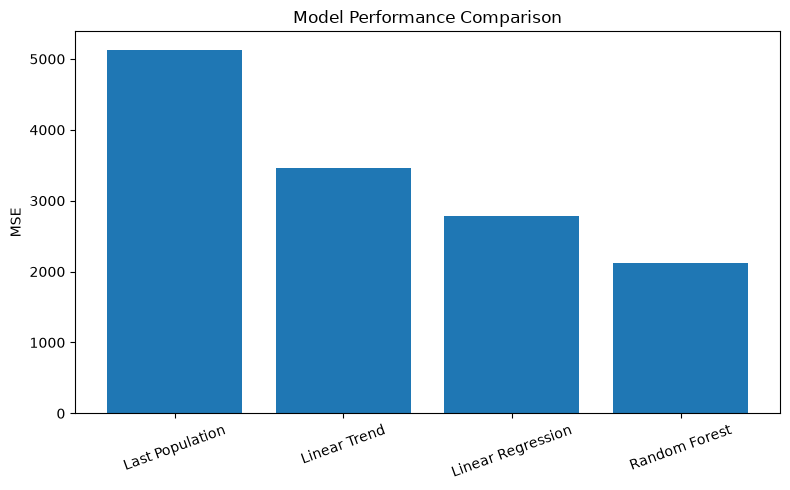

In [342]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["model"],
    model_comparison["MSE"]
)

plt.ylabel("MSE")
plt.title("Model Performance Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "10_model_comparison.png",
    dpi=300
)

plt.show()

# 查看预测最差的城市

In [343]:
model_features = model_data[
    ["city_id"] + features + [target, "target_year"]
].copy()

train_data = model_features.dropna(
    subset=features + [target]
).copy()

train = train_data[
    train_data["target_year"] < 2021
].copy()

valid = train_data[
    train_data["target_year"] == 2021
].copy()

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

#训练再一次
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_valid)

#做表
rf_result = valid[
    [
        "city_id",
        "target_year",
        target
    ]
].copy()

rf_result["prediction"] = pred_rf

rf_result["error"] = (
    rf_result["prediction"]
    - rf_result[target]
)

rf_result["abs_error"] = (
    rf_result["error"].abs()
)

# 看误差最大10个回测eda的发现

# 看rf认为重要的特征

In [344]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_importance.to_csv(
    DATA_DIR + "rf_feature_importance.csv",
    index=False
)

# 检查模型mse评分效果

In [345]:
print("Random Forest MSE:", mse_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MSE: 2128.2448563881944
Random Forest RMSE: 46.13290427003479


# 保存当前比较结果

In [346]:
model_comparison = pd.DataFrame({
    "model": [
        "Last Population",
        "Linear Trend",
        "Linear Regression",
        "Random Forest"
    ],
    "MSE": [
        5133.05,
        3457.55,
        mse_lr,
        mse_rf
    ],
    "RMSE": [
        71.64530689445053,
        58.80093536670994,
        rmse_lr,
        rmse_rf
    ]
})
model_comparison.to_csv(
    DATA_DIR + "model_comparison.csv",
    index=False
)

# 看rf的特征重要性

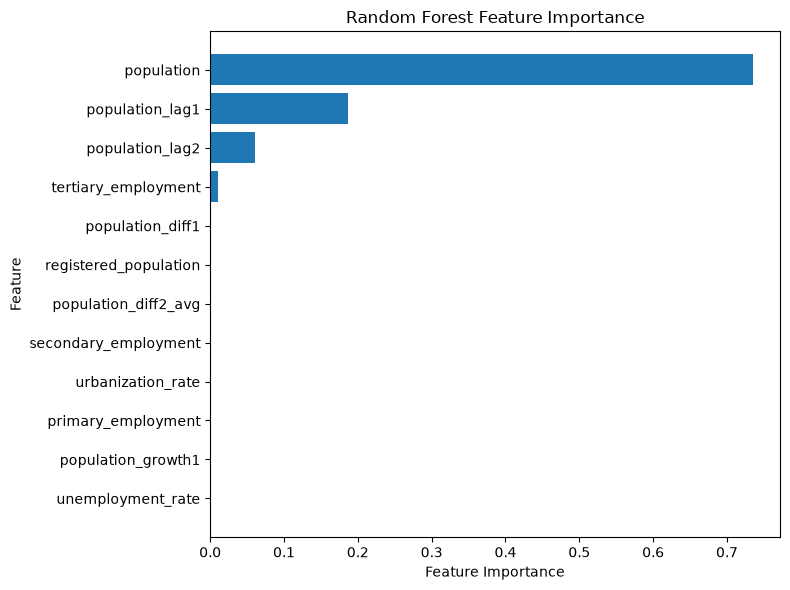

In [347]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)
#保存
feature_importance.to_csv(
    DATA_DIR + "rf_feature_importance.csv",
    index=False
)
#作图
plt.figure(figsize=(8, 6))

importance_plot = feature_importance.sort_values(
    "importance"
)

plt.barh(
    importance_plot["feature"],
    importance_plot["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "11_rf_feature_importance.png",
    dpi=300
)

plt.show()

# 查看rf预测最差的城市，联系eda的结论

In [348]:
rf_result = valid[
    [
        "city_id",
        "target_year",
        target
    ]
].copy()

rf_result["prediction"] = pred_rf

rf_result["error"] = (
    rf_result["prediction"]
    - rf_result[target]
)

rf_result["abs_error"] = (
    rf_result["error"].abs()
)

rf_result = rf_result.sort_values(
    "abs_error",
    ascending=False
)


rf_result.to_csv(
    DATA_DIR + "rf_validation_detail.csv",
    index=False
)

# 准备独立test

In [349]:
test_model = test.copy()
#统一命名
test_model = test_model.rename(columns={
    "年份": "year",
    "常住人口": "population",
    "城镇化率": "urbanization_rate",
    "失业率": "unemployment_rate",
    "第一产业人数": "primary_employment",
    "第二产业人数": "secondary_employment",
    "第三产业人数": "tertiary_employment",
    "户籍人口": "registered_population",
    "人均可支配收入": "disposable_income",
    "城镇居民消费支出": "urban_consumption_expenditures"
})
#排序
test_model = (
    test_model
    .sort_values("year")
    .reset_index(drop=True)
)
#构造历史特征
test_model["population_lag1"] = (
    test_model["population"].shift(1)
)

test_model["population_lag2"] = (
    test_model["population"].shift(2)
)
#变化量
test_model["population_diff1"] = (
    test_model["population"]
    - test_model["population_lag1"]
)
#增长率
test_model["population_growth1"] = np.where(
    test_model["population_lag1"] > 0,

    (
        test_model["population"]
        - test_model["population_lag1"]
    )
    / test_model["population_lag1"],

    np.nan
)
#每2年平均变化
test_model["population_diff2_avg"] = (
    (
        test_model["population"]
        - test_model["population_lag2"]
    ) / 2
)

#检查
test_model[
    [
        "year",
        "population",
        "population_lag1",
        "population_lag2",
        "population_diff1",
        "population_growth1",
        "population_diff2_avg"
    ]
]



,year,population,population_lag1,population_lag2,population_diff1,population_growth1,population_diff2_avg
0,2014,414,NaN,NaN,NaN,NaN,NaN
1,2015,411,414.0,NaN,-3.0,-0.007246,NaN
2,2016,407,411.0,414.0,-4.0,-0.009732,-3.5
3,2017,404,407.0,411.0,-3.0,-0.007371,-3.5
4,2018,400,404.0,407.0,-4.0,-0.009901,-3.5
5,2019,396,400.0,404.0,-4.0,-0.010000,-4.0
6,2020,392,396.0,400.0,-4.0,-0.010101,-4.0
7,2021,387,392.0,396.0,-5.0,-0.012755,-4.5
8,2022,388,387.0,392.0,1.0,0.002584,-2.0
9,2023,384,388.0,387.0,-4.0,-0.010309,-1.5


# 取2021为最终预测，并且用rf预测2023

In [350]:
test_2021 = test_model[
    test_model["year"] == 2021
].copy()

test_2021[features].T

test_2021[features].isna().sum()

pred_test_rf = rf.predict(
    test_2021[features]
)[0]

print(
    "Random Forest 预测 2023 人口:",
    pred_test_rf
)


test_2023_true = test_model.loc[
    test_model["year"] == 2023,
    "population"
].iloc[0]

rf_test_error = (
    pred_test_rf
    - test_2023_true
)

print("真实人口:", test_2023_true)
print("预测人口:", pred_test_rf)
print("绝对误差:", abs(rf_test_error))
print("平方误差:", rf_test_error ** 2)

Random Forest 预测 2023 人口: 398.59272422230765
真实人口: 384
预测人口: 398.59272422230765
绝对误差: 14.592724222307652
平方误差: 212.94760022832446


# 保存结论

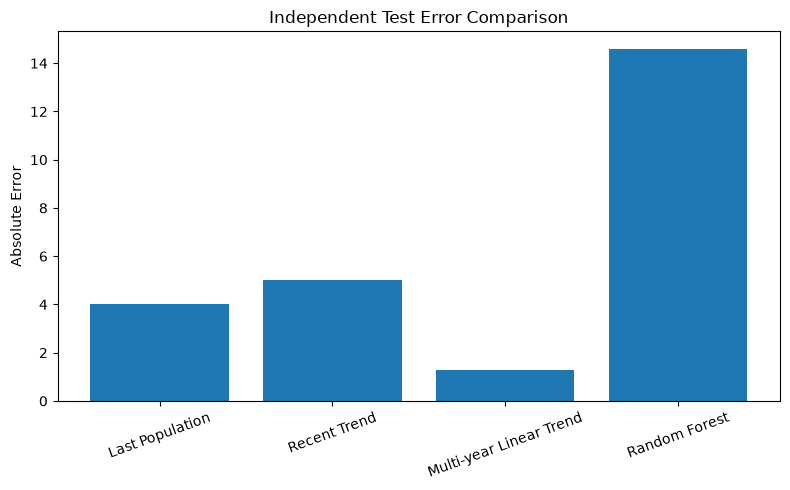

In [351]:
final_test_result = pd.DataFrame({
    "model": [
        "Last Population",
        "Recent Trend",
        "Multi-year Linear Trend",
        "Random Forest"
    ],

    "prediction_2023": [
        388.0,
        389.0,
        382.7,
        pred_test_rf
    ],

    "true_2023": [
        384,
        384,
        384,
        384
    ]
})
#计算误差
final_test_result["absolute_error"] = abs(
    final_test_result["prediction_2023"]
    - final_test_result["true_2023"]
)

final_test_result["squared_error"] = (
    final_test_result["prediction_2023"]
    - final_test_result["true_2023"]
) ** 2

#保存
final_test_result.to_csv(
    DATA_DIR + "final_test_result.csv",
    index=False
)

#作图
plt.figure(figsize=(8, 5))

plt.bar(
    final_test_result["model"],
    final_test_result["absolute_error"]
)

plt.ylabel("Absolute Error")
plt.title("Independent Test Error Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "12_independent_test_error.png",
    dpi=300
)

plt.show()

# 最终预测结论（ai协助提供）（这部分做ppt得用自己的话重新撰写一次）

在历史多城市验证实验中，Random Forest 的 MSE 为 2128.24、RMSE 为 46.13，在所比较方法中取得最佳整体预测性能，说明人口历史特征及社会经济指标之间存在一定非线性关系。

在独立测试序列的 2023 年预测中，Random Forest 预测为 398.59 万人，而真实人口为 384 万人，绝对误差为 14.59 万人。相比之下，基于 2018–2022 年长期趋势建立的线性预测结果为 382.7 万人，绝对误差仅为 1.3 万人。

结果表明，复杂模型在多城市总体样本上的平均预测能力较强，但对于趋势长期稳定的单一城市序列，简单的时间趋势模型可能具有更好的局部适用性。因此模型复杂度并不必然与单一样本上的预测精度成正比。